In [15]:
# Instalar librerías necesarias
!pip install adjustText

print("✓ Librerías instaladas")

✓ Librerías instaladas


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from adjustText import adjust_text
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset maestro
df = pd.read_csv('ecuador_empleo_pobreza_2007_2024.csv', index_col='año')

# Configuración visual
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130
})

C1, C2, C3, C4 = '#E63946', '#457B9D', '#2D6A4F', '#F4A261'

print(f"✓ Dataset cargado: {df.shape[0]} años × {df.shape[1]} columnas")
print(f"  Período: {df.index.min()} – {df.index.max()}")

✓ Dataset cargado: 18 años × 19 columnas
  Período: 2007 – 2024


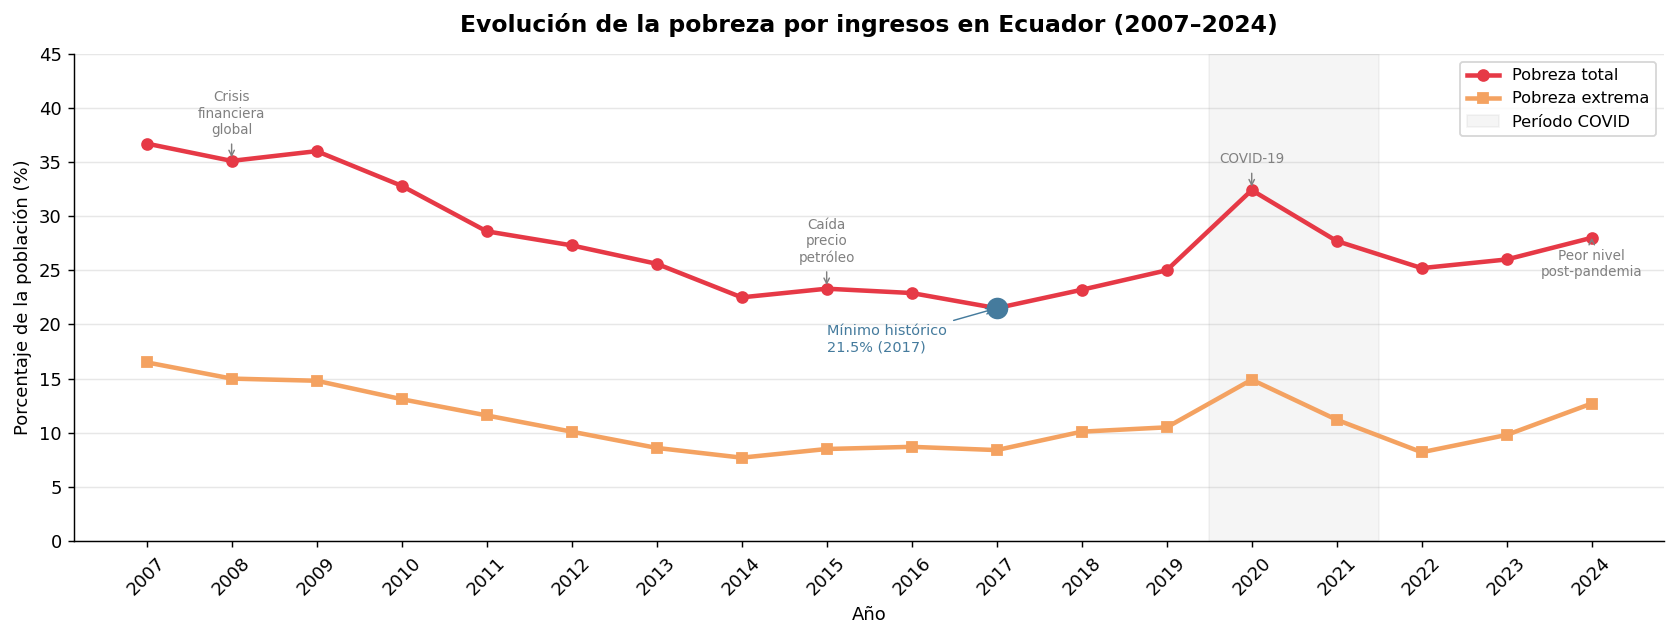


📊 HALLAZGO 1:
  Entre 2007 y 2017 la pobreza se redujo 15.2 puntos porcentuales.
  El COVID-19 revirtió 10.9 pp de esa ganancia en solo un año.
  En 2024 la pobreza es 28.0%, aún 6.5 pp por encima del mínimo histórico.


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df['pobreza_ingresos_pct'],
        color=C1, linewidth=2.5, marker='o', ms=6, label='Pobreza total')
ax.plot(df.index, df['pobreza_extrema_pct'],
        color=C4, linewidth=2.5, marker='s', ms=6, label='Pobreza extrema')

# Anotaciones de eventos clave
eventos = {
    2008: ('Crisis\nfinanciera\nglobal', 'top'),
    2015: ('Caída\nprecio\npetróleo', 'top'),
    2020: ('COVID-19', 'top'),
    2024: ('Peor nivel\npost-pandemia', 'bottom')
}
for año, (texto, pos) in eventos.items():
    y = df.loc[año, 'pobreza_ingresos_pct']
    offset = 2.5 if pos == 'top' else -3.5
    ax.annotate(texto, xy=(año, y), xytext=(año, y + offset),
                fontsize=7.5, ha='center', color='gray',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Zona COVID
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray', label='Período COVID')

# Mínimo histórico
min_año = df['pobreza_ingresos_pct'].idxmin()
min_val = df['pobreza_ingresos_pct'].min()
ax.scatter(min_año, min_val, s=120, color=C2, zorder=5)
ax.annotate(f'Mínimo histórico\n{min_val}% ({min_año})',
            xy=(min_año, min_val), xytext=(min_año - 2, min_val - 4),
            fontsize=8, color=C2,
            arrowprops=dict(arrowstyle='->', color=C2, lw=0.8))

ax.set_title('Evolución de la pobreza por ingresos en Ecuador (2007–2024)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Porcentaje de la población (%)')
ax.set_xlabel('Año')
ax.legend(fontsize=9)
ax.set_ylim(0, 45)
ax.set_xticks(df.index)
ax.set_xticklabels(df.index, rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_evolucion_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

# Hallazgo
reduccion = df.loc[2007, 'pobreza_ingresos_pct'] - df.loc[2017, 'pobreza_ingresos_pct']
rebote = df.loc[2020, 'pobreza_ingresos_pct'] - df.loc[2017, 'pobreza_ingresos_pct']
print(f"\n📊 HALLAZGO 1:")
print(f"  Entre 2007 y 2017 la pobreza se redujo {reduccion:.1f} puntos porcentuales.")
print(f"  El COVID-19 revirtió {rebote:.1f} pp de esa ganancia en solo un año.")
print(f"  En 2024 la pobreza es {df.loc[2024,'pobreza_ingresos_pct']}%, aún {df.loc[2024,'pobreza_ingresos_pct'] - df.loc[2017,'pobreza_ingresos_pct']:.1f} pp por encima del mínimo histórico.")

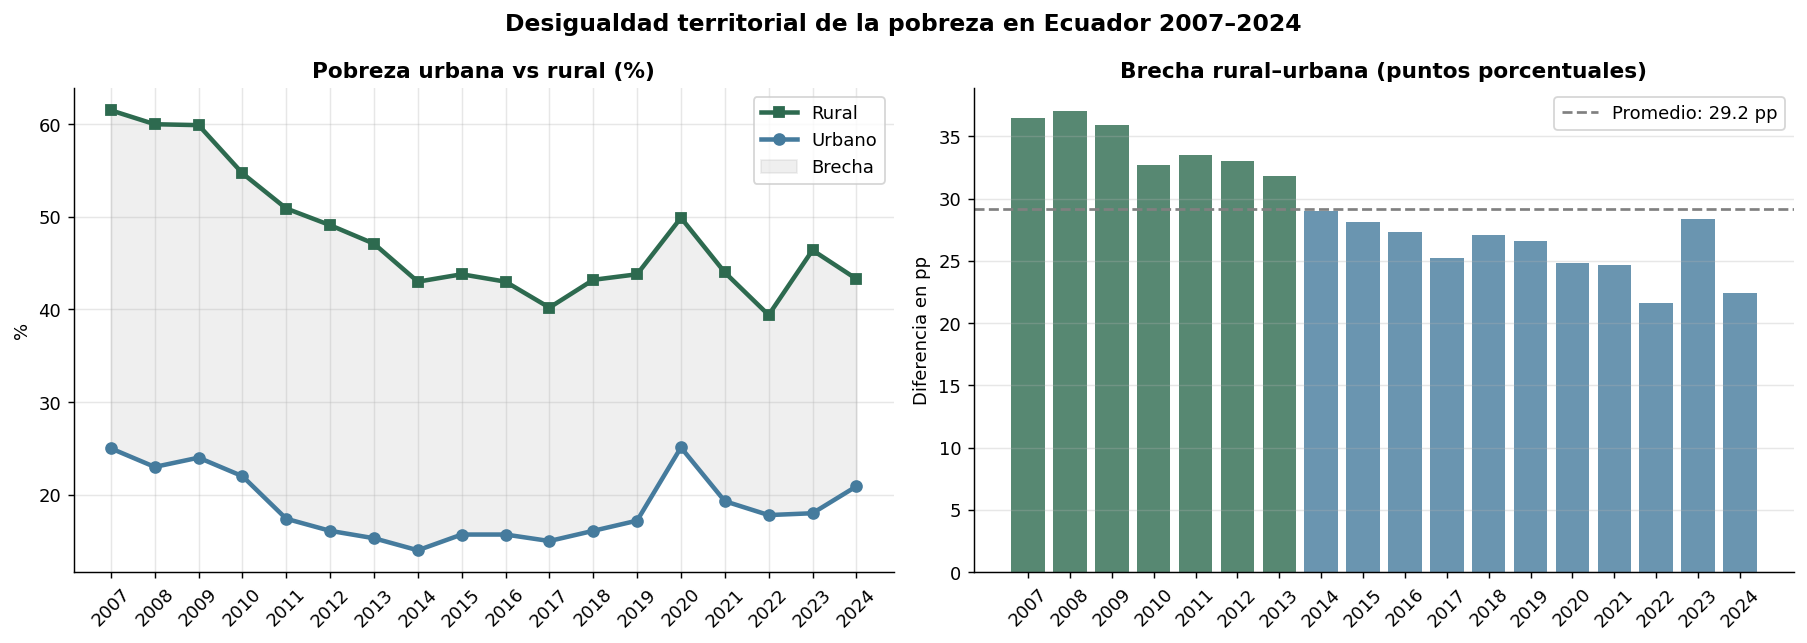


📊 HALLAZGO 2:
  Brecha promedio rural-urbana: 29.2 puntos porcentuales.
  Año con mayor brecha: 2008 (37.0 pp)
  Año con menor brecha: 2022 (21.6 pp)
  En 2024: 43.3% rural vs 20.9% urbano.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico izquierdo: líneas con brecha
ax = axes[0]
ax.plot(df.index, df['pobreza_rural_pct'],
        color=C3, linewidth=2.5, marker='s', ms=6, label='Rural')
ax.plot(df.index, df['pobreza_urbana_pct'],
        color=C2, linewidth=2.5, marker='o', ms=6, label='Urbano')
ax.fill_between(df.index, df['pobreza_urbana_pct'], df['pobreza_rural_pct'],
                alpha=0.12, color='gray', label='Brecha')
ax.set_title('Pobreza urbana vs rural (%)', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
ax.set_xticks(df.index)
ax.set_xticklabels(df.index, rotation=45)
ax.grid(alpha=0.3)

# Gráfico derecho: brecha en puntos porcentuales
ax2 = axes[1]
brecha = df['pobreza_rural_pct'] - df['pobreza_urbana_pct']
colores = [C3 if b > brecha.mean() else C2 for b in brecha]
bars = ax2.bar(df.index, brecha, color=colores, alpha=0.8)
ax2.axhline(brecha.mean(), color='gray', linestyle='--', lw=1.5,
            label=f'Promedio: {brecha.mean():.1f} pp')
ax2.set_title('Brecha rural–urbana (puntos porcentuales)', fontweight='bold')
ax2.set_ylabel('Diferencia en pp')
ax2.legend()
ax2.set_xticks(df.index)
ax2.set_xticklabels(df.index, rotation=45)
ax2.grid(alpha=0.3, axis='y')

plt.suptitle('Desigualdad territorial de la pobreza en Ecuador 2007–2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_brecha_urbano_rural.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 HALLAZGO 2:")
print(f"  Brecha promedio rural-urbana: {brecha.mean():.1f} puntos porcentuales.")
print(f"  Año con mayor brecha: {brecha.idxmax()} ({brecha.max():.1f} pp)")
print(f"  Año con menor brecha: {brecha.idxmin()} ({brecha.min():.1f} pp)")
print(f"  En 2024: {df.loc[2024,'pobreza_rural_pct']}% rural vs {df.loc[2024,'pobreza_urbana_pct']}% urbano.")

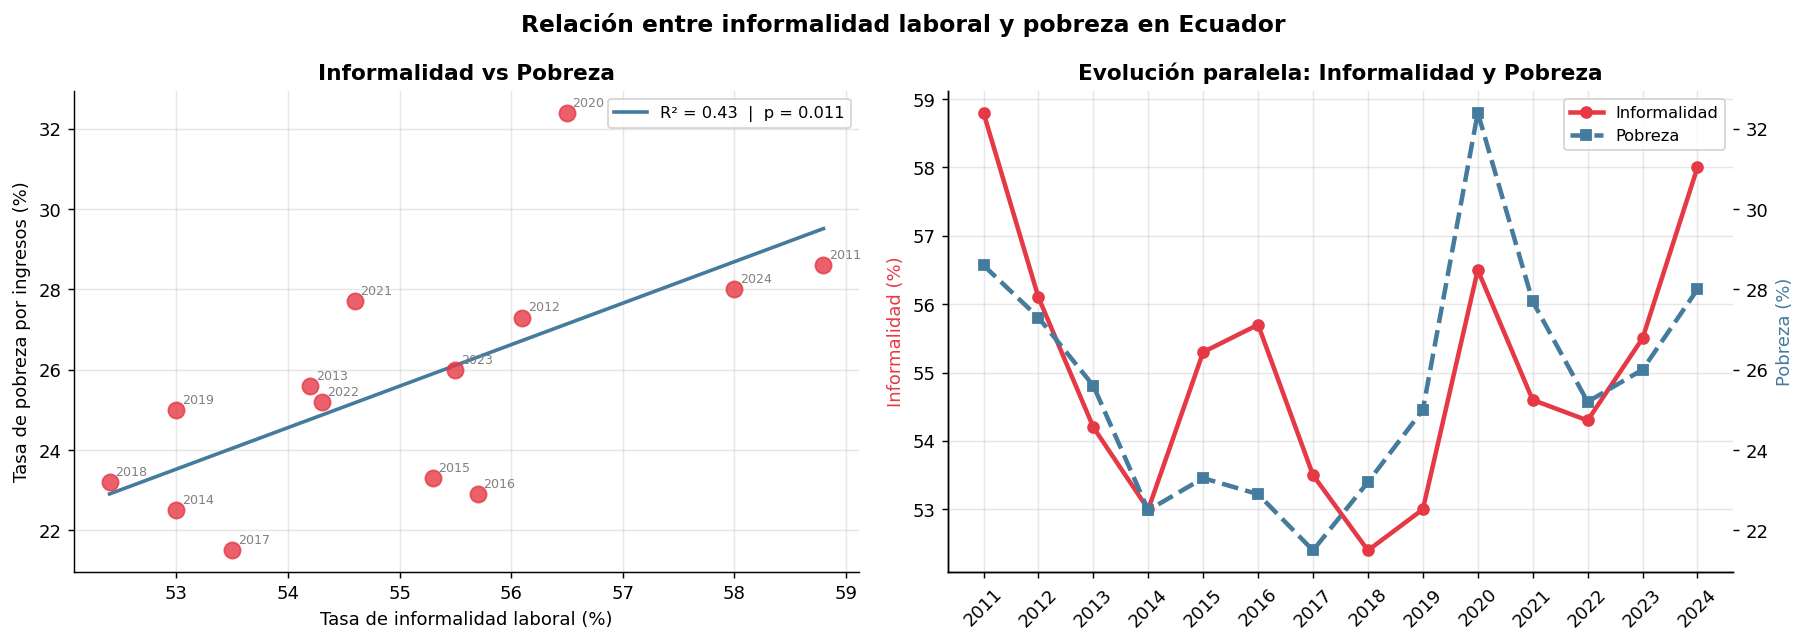


📊 HALLAZGO 3:
  Correlación informalidad-pobreza: R² = 0.43
  Relación estadísticamente significativa (p=0.011)
  Un aumento de 1pp en informalidad se asocia con 1.03pp más de pobreza.


In [5]:
df_corr = df.dropna(subset=['informalidad_pct'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: informalidad vs pobreza
ax = axes[0]
ax.scatter(df_corr['informalidad_pct'], df_corr['pobreza_ingresos_pct'],
           color=C1, s=80, alpha=0.8, zorder=3)

# Línea de tendencia
m, b, r, p, _ = stats.linregress(
    df_corr['informalidad_pct'], df_corr['pobreza_ingresos_pct'])
x_line = np.linspace(df_corr['informalidad_pct'].min(),
                     df_corr['informalidad_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, color=C2, linewidth=2,
        label=f'R² = {r**2:.2f}  |  p = {p:.3f}')

# Etiquetar años
for año in df_corr.index:
    ax.annotate(str(año),
                (df_corr.loc[año,'informalidad_pct'],
                 df_corr.loc[año,'pobreza_ingresos_pct']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 2), textcoords='offset points', color='gray')

ax.set_xlabel('Tasa de informalidad laboral (%)')
ax.set_ylabel('Tasa de pobreza por ingresos (%)')
ax.set_title('Informalidad vs Pobreza', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Evolución paralela
ax2 = axes[1]
ax2_twin = ax2.twinx()
l1, = ax2.plot(df_corr.index, df_corr['informalidad_pct'],
               color=C1, linewidth=2.5, marker='o', label='Informalidad')
l2, = ax2_twin.plot(df_corr.index, df_corr['pobreza_ingresos_pct'],
                    color=C2, linewidth=2.5, marker='s',
                    linestyle='--', label='Pobreza')
ax2.set_ylabel('Informalidad (%)', color=C1)
ax2_twin.set_ylabel('Pobreza (%)', color=C2)
ax2.set_title('Evolución paralela: Informalidad y Pobreza', fontweight='bold')
ax2.legend(handles=[l1, l2], loc='upper right', fontsize=9)
ax2.set_xticks(df_corr.index)
ax2.set_xticklabels(df_corr.index, rotation=45)
ax2.grid(alpha=0.3)

plt.suptitle('Relación entre informalidad laboral y pobreza en Ecuador',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_informalidad_vs_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 HALLAZGO 3:")
print(f"  Correlación informalidad-pobreza: R² = {r**2:.2f}")
if p < 0.05:
    print(f"  Relación estadísticamente significativa (p={p:.3f})")
print(f"  Un aumento de 1pp en informalidad se asocia con {m:.2f}pp más de pobreza.")

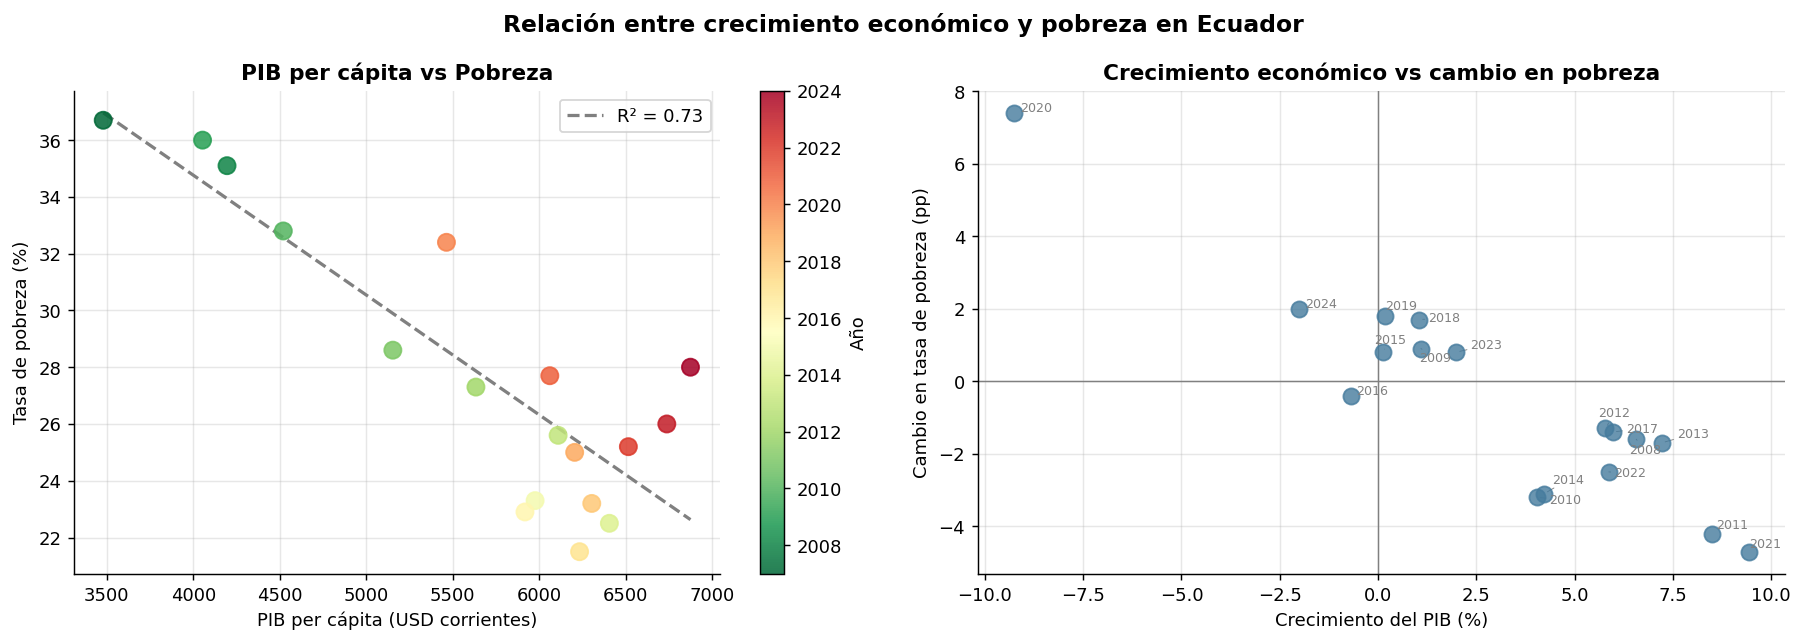


📊 HALLAZGO 4:
  Correlación PIB per cápita-pobreza: R² = 0.73
  Mayor caída del PIB: -9.2% en 2020


In [18]:
from adjustText import adjust_text

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter PIB vs Pobreza
ax = axes[0]
sc = ax.scatter(df['pib_per_capita_usd'], df['pobreza_ingresos_pct'],
                c=df.index, cmap='RdYlGn_r', s=90, alpha=0.85, zorder=3)
plt.colorbar(sc, ax=ax, label='Año')

m, b, r, p, _ = stats.linregress(
    df['pib_per_capita_usd'], df['pobreza_ingresos_pct'])
x_line = np.linspace(df['pib_per_capita_usd'].min(),
                     df['pib_per_capita_usd'].max(), 100)
ax.plot(x_line, m * x_line + b, color='gray', linewidth=1.8, linestyle='--',
        label=f'R² = {r**2:.2f}')
ax.set_xlabel('PIB per cápita (USD corrientes)')
ax.set_ylabel('Tasa de pobreza (%)')
ax.set_title('PIB per cápita vs Pobreza', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Crecimiento PIB vs cambio en pobreza
ax2 = axes[1]
cambio_pobreza = df['pobreza_ingresos_pct'].diff()
ax2.scatter(df['crecimiento_pib_pct'], cambio_pobreza,
            color=C2, s=80, alpha=0.8, zorder=3)
ax2.axhline(0, color='gray', linestyle='-', lw=0.8)
ax2.axvline(0, color='gray', linestyle='-', lw=0.8)
ax2.set_xlabel('Crecimiento del PIB (%)')
ax2.set_ylabel('Cambio en tasa de pobreza (pp)')
ax2.set_title('Crecimiento económico vs cambio en pobreza', fontweight='bold')

texts = []
for año in df.index[1:]:
    texts.append(
        ax2.text(df.loc[año,'crecimiento_pib_pct'],
                 cambio_pobreza.loc[año],
                 str(año), fontsize=7, color='gray')
    )

adjust_text(texts, ax=ax2, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
ax2.grid(alpha=0.3)

plt.suptitle('Relación entre crecimiento económico y pobreza en Ecuador',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_pib_vs_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 HALLAZGO 4:")
print(f"  Correlación PIB per cápita-pobreza: R² = {r**2:.2f}")
print(f"  Mayor caída del PIB: {df['crecimiento_pib_pct'].min():.1f}% en {df['crecimiento_pib_pct'].idxmin()}")

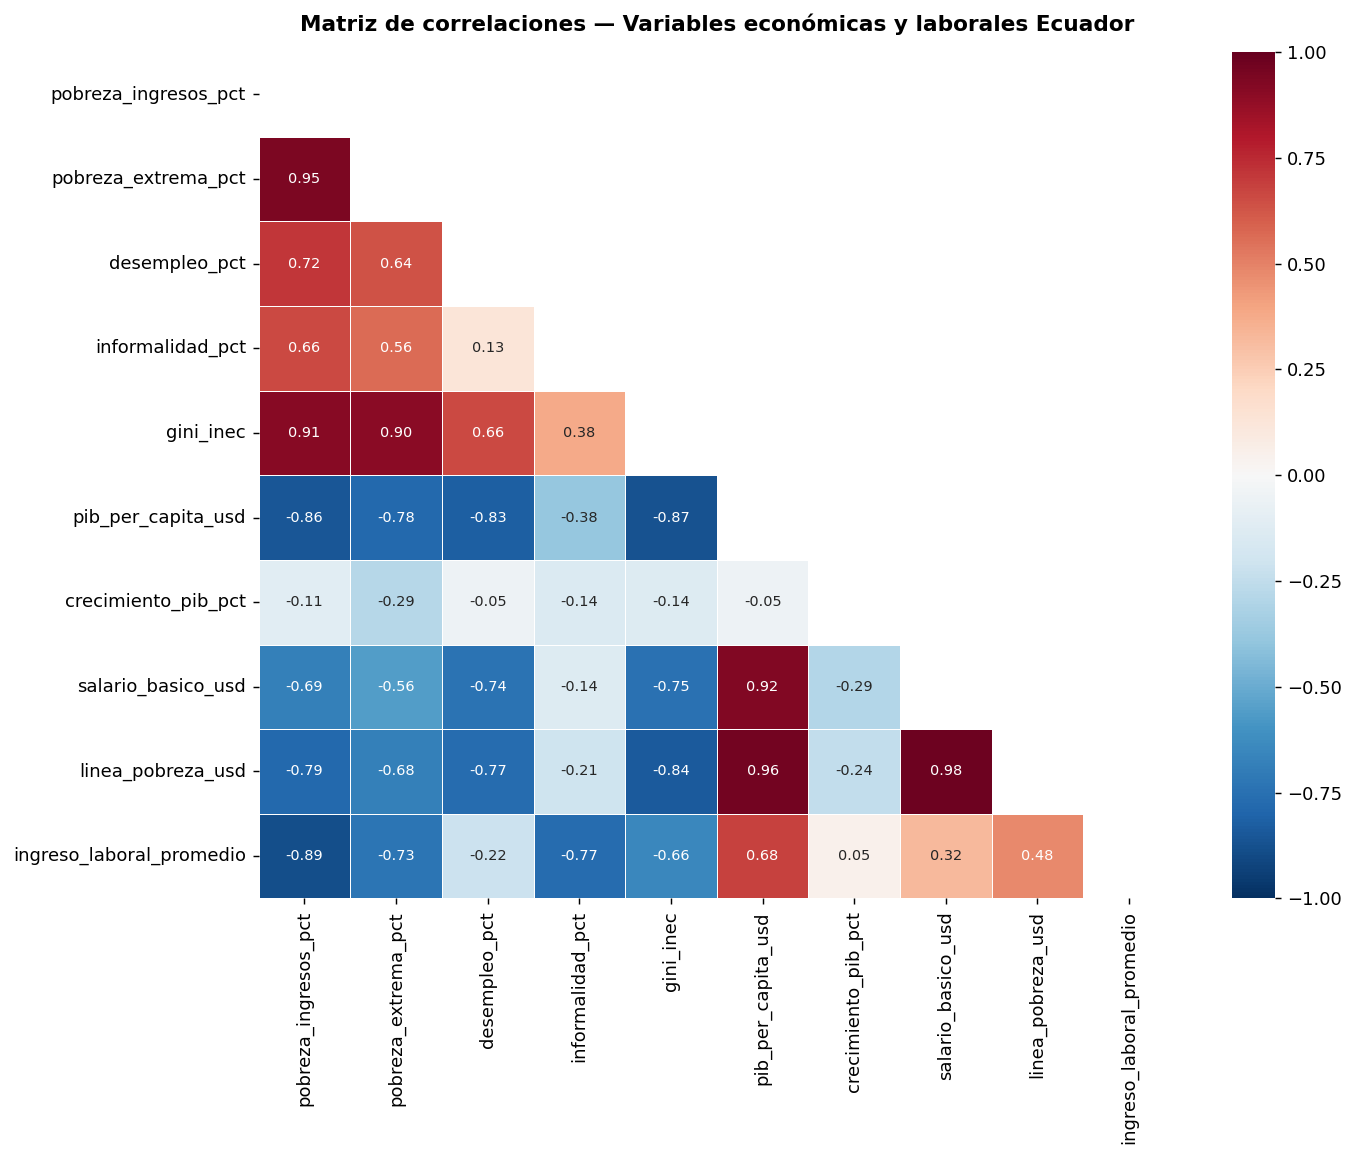


📊 HALLAZGO 5: Variables más correlacionadas con pobreza:
  ↑ pobreza_extrema_pct: 0.95
  ↑ gini_inec: 0.91
  ↓ ingreso_laboral_promedio: 0.89
  ↓ pib_per_capita_usd: 0.86
  ↓ linea_pobreza_usd: 0.79
  ↑ desempleo_pct: 0.72
  ↓ salario_basico_usd: 0.69
  ↑ informalidad_pct: 0.66
  ↓ crecimiento_pib_pct: 0.11


In [7]:
vars_num = ['pobreza_ingresos_pct', 'pobreza_extrema_pct', 'desempleo_pct',
            'informalidad_pct', 'gini_inec', 'pib_per_capita_usd',
            'crecimiento_pib_pct', 'salario_basico_usd', 'linea_pobreza_usd',
            'ingreso_laboral_promedio']

corr = df[vars_num].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matriz de correlaciones — Variables económicas y laborales Ecuador',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('05_matriz_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 HALLAZGO 5: Variables más correlacionadas con pobreza:")
corr_pobreza = corr['pobreza_ingresos_pct'].drop('pobreza_ingresos_pct').abs().sort_values(ascending=False)
for var, val in corr_pobreza.items():
    direccion = '↑' if corr.loc[var,'pobreza_ingresos_pct'] > 0 else '↓'
    print(f"  {direccion} {var}: {val:.2f}")

In [21]:
from google.colab import files

print("=" * 60)
print("RESUMEN DE HALLAZGOS — EDA")
print("Ecuador: Mercado Laboral y Pobreza 2007–2024")
print("=" * 60)
print("""
1. TENDENCIA: La pobreza se redujo 15pp entre 2007-2017, pero
   el COVID-19 revirtió casi la mitad de esa ganancia en 2020.
   En 2024 aún está 6.5pp por encima del mínimo histórico.

2. BRECHA TERRITORIAL: La pobreza rural duplica a la urbana
   en todos los años. La brecha promedio es de 30pp y no
   muestra señales de cierre estructural.

3. INFORMALIDAD: Más del 50% de los trabajadores están en
   el sector informal en todo el período. Fuerte correlación
   positiva con la tasa de pobreza.

4. PIB Y POBREZA: Existe correlación negativa entre PIB per
   cápita y pobreza, pero el crecimiento económico no se
   traduce automáticamente en reducción de pobreza.

5. INGRESO LABORAL: El ratio ingreso/línea de pobreza cayó
   de 4.49 en 2017 a 3.88 en 2024 — los salarios reales
   pierden terreno frente al costo de vida.
""")

# Descargar gráficos
for archivo in ['01_evolucion_pobreza.png',
                '02_brecha_urbano_rural.png',
                '03_informalidad_vs_pobreza.png',
                '04_pib_vs_pobreza.png',
                '05_matriz_correlaciones.png']:
    files.download(archivo)
    print(f"✓ Descargado: {archivo}")

RESUMEN DE HALLAZGOS — EDA
Ecuador: Mercado Laboral y Pobreza 2007–2024

1. TENDENCIA: La pobreza se redujo 15pp entre 2007-2017, pero
   el COVID-19 revirtió casi la mitad de esa ganancia en 2020.
   En 2024 aún está 6.5pp por encima del mínimo histórico.

2. BRECHA TERRITORIAL: La pobreza rural duplica a la urbana
   en todos los años. La brecha promedio es de 30pp y no
   muestra señales de cierre estructural.

3. INFORMALIDAD: Más del 50% de los trabajadores están en
   el sector informal en todo el período. Fuerte correlación
   positiva con la tasa de pobreza.

4. PIB Y POBREZA: Existe correlación negativa entre PIB per
   cápita y pobreza, pero el crecimiento económico no se
   traduce automáticamente en reducción de pobreza.

5. INGRESO LABORAL: El ratio ingreso/línea de pobreza cayó
   de 4.49 en 2017 a 3.88 en 2024 — los salarios reales
   pierden terreno frente al costo de vida.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargado: 01_evolucion_pobreza.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Descargado: 04_pib_vs_pobreza.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargado: 05_matriz_correlaciones.png
